# import libs

In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sqlite3
import plotly.express as px
import holidays
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.formula.api import glm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error
from keras import Sequential
from keras import layers
from keras.models import Model
from keras.layers import LSTM, BatchNormalization, Dropout, Dense, Flatten, Conv1D
from keras.layers import MaxPooling1D, GRU, Input,Masking, Concatenate, dot
from keras.optimizers import Adam, SGD
from keras.losses import MeanAbsoluteError
from keras.metrics import RootMeanSquaredError
from keras.callbacks import EarlyStopping
from keras.callbacks import LearningRateScheduler
import xgboost as xgb
import tensorflow as tf
import tensorflow_addons as tfa
import shap

In [2]:
import nbimporter
%run -i Common_Functions.ipynb
from Common_Functions import *

# load data

In [3]:
file_path = "NEM Registration and Exemption List.xlsx"
df_participants = pd.read_excel(file_path, sheet_name='PU and Scheduled Loads')

In [5]:
df_scada_hour = pd.read_csv('processed_data_files/SCADA_NOTJOINED_FILTER_SCADAgreaterthan0_groupby_hour_duid_sum.csv')
df_participants_select = df_participants[['Fuel Source - Descriptor', 'DUID', 'Technology Type - Primary', 'Region']]
df_scada_merged_participants = df_scada_hour.merge(df_participants_select, on="DUID", how="left")
df_scada_merged_participants = df_scada_merged_participants[df_scada_merged_participants['DATE'] < '2025-01-01']

In [4]:
df_price = pd.read_csv('processed_data_files/PRICE_groupby_hour_regionid_avg.csv')
df_demand = pd.read_csv('processed_data_files/DEMAND_groupby_hour_regionid_sum.csv')

In [7]:
df_scada_merged_participants.head()

,DATE,HOUR,DUID,SCADAVALUE,Fuel Source - Descriptor,Technology Type - Primary,Region
0,2019-01-01,0,AGLHAL,0.00,Natural Gas / Diesel,Combustion,SA1
1,2019-01-01,0,AGLSOM,0.00,Natural Gas,Combustion,VIC1
2,2019-01-01,0,ANGAST1,0.00,Diesel,Combustion,SA1
3,2019-01-01,0,ARWF1,500.60,Wind,Renewable,VIC1
4,2019-01-01,0,BALBG1,4.07,NaN,NaN,NaN


In [8]:
df_scada_merged_participants.shape

(20750464, 7)

In [14]:
df_scada_qld = df_scada_merged_participants[df_scada_merged_participants['Region'] == 'QLD1']

In [16]:
df_scada_qld.shape

(4559338, 7)

In [10]:
df_price.head()

,REGIONID,Date_Hour,RRP
0,NSW1,2019-01-01 00:00:00,68.191979
1,NSW1,2019-01-01 01:00:00,71.477868
2,NSW1,2019-01-01 02:00:00,65.966705
3,NSW1,2019-01-01 03:00:00,56.840463
4,NSW1,2019-01-01 04:00:00,52.360826


In [17]:
df_price_qld = df_price[df_price['REGIONID'] == 'QLD1']
df_demand_qld = df_demand[df_demand['REGIONID'] == 'QLD1']

In [18]:
df_demand_qld.shape

(2223, 3)

In [19]:
df_demand_qld.head()

,REGIONID,Date_Hour,RESDEMAND
2223,QLD1,2019-01-01 00:00:00,115674373.0
2224,QLD1,2019-01-02 00:00:00,123473992.0
2225,QLD1,2019-01-03 00:00:00,122851746.0
2226,QLD1,2019-01-04 00:00:00,122740848.0
2227,QLD1,2019-01-05 00:00:00,118949941.0


In [20]:
df_demand_qld.tail()

,REGIONID,Date_Hour,RESDEMAND
4441,QLD1,2025-01-27 00:00:00,69927540.0
4442,QLD1,2025-01-28 00:00:00,72512229.0
4443,QLD1,2025-01-29 00:00:00,75613010.0
4444,QLD1,2025-01-30 00:00:00,75785536.0
4445,QLD1,2025-01-31 00:00:00,77070034.0


In [21]:
df_price_qld.head()

,REGIONID,Date_Hour,RRP
53353,QLD1,2019-01-01 00:00:00,64.605948
53354,QLD1,2019-01-01 01:00:00,66.544864
53355,QLD1,2019-01-01 02:00:00,61.140174
53356,QLD1,2019-01-01 03:00:00,52.883149
53357,QLD1,2019-01-01 04:00:00,49.505579


In [52]:
df_scada_qld['Date_Hour'] = df_scada_qld['DATE'].astype(str) + ' ' + df_scada_qld['HOUR'].astype(str).str.zfill(2) + ':00:00'

df_scada_qld.head()

/var/folders/b6/bmslj24d11n41826_8m7yb400000gn/T/ipykernel_6437/3840564399.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_scada_qld['Date_Hour'] = df_scada_qld['DATE'].astype(str) + ' ' + df_scada_qld['HOUR'].astype(str).str.zfill(2) + ':00:00'


,DATE,HOUR,DUID,SCADAVALUE,Fuel Source - Descriptor,Technology Type - Primary,Region,Date_Hour
8,2019-01-01,0,BARCALDN,0.00,Natural Gas,Combustion,QLD1,2019-01-01 00:00:00
9,2019-01-01,0,BARCSF1,5.50,Solar,Renewable,QLD1,2019-01-01 00:00:00
10,2019-01-01,0,BARRON-1,366.84,Water,Renewable,QLD1,2019-01-01 00:00:00
11,2019-01-01,0,BARRON-2,364.80,Water,Renewable,QLD1,2019-01-01 00:00:00
24,2019-01-01,0,BRAEMAR1,0.00,Coal Seam Methane,Combustion,QLD1,2019-01-01 00:00:00


In [53]:
df_scada_qld[df_scada_qld['Date_Hour'] == '2019-01-01 00:00:00']

,DATE,HOUR,DUID,SCADAVALUE,Fuel Source - Descriptor,Technology Type - Primary,Region,Date_Hour
8,2019-01-01,0,BARCALDN,0.00,Natural Gas,Combustion,QLD1,2019-01-01 00:00:00
9,2019-01-01,0,BARCSF1,5.50,Solar,Renewable,QLD1,2019-01-01 00:00:00
10,2019-01-01,0,BARRON-1,366.84,Water,Renewable,QLD1,2019-01-01 00:00:00
11,2019-01-01,0,BARRON-2,364.80,Water,Renewable,QLD1,2019-01-01 00:00:00
24,2019-01-01,0,BRAEMAR1,0.00,Coal Seam Methane,Combustion,QLD1,2019-01-01 00:00:00
...,...,...,...,...,...,...,...,...
285,2019-01-01,0,W/HOE#2,0.00,Water,Renewable,QLD1,2019-01-01 00:00:00
290,2019-01-01,0,WHITSF1,0.00,Solar,Renewable,QLD1,2019-01-01 00:00:00
298,2019-01-01,0,YABULU,0.00,Natural Gas,Combustion,QLD1,2019-01-01 00:00:00
299,2019-01-01,0,YABULU2,0.00,Natural Gas,Combustion,QLD1,2019-01-01 00:00:00


# process data

In [54]:
df_scada_qld_groupbytime = df_scada_qld.groupby(['Date_Hour', 'Fuel Source - Descriptor'])['SCADAVALUE'].sum().reset_index()
df_scada_qld_groupbytime.head()

,Date_Hour,Fuel Source - Descriptor,SCADAVALUE
0,2019-01-01 00:00:00,-,0.00000
1,2019-01-01 00:00:00,Black Coal,62858.98551
2,2019-01-01 00:00:00,Coal Seam Methane,0.00000
3,2019-01-01 00:00:00,Kerosene,0.00000
4,2019-01-01 00:00:00,Natural Gas,3975.97976


In [55]:
df_scada_qld_groupbytime = df_scada_qld_groupbytime[df_scada_qld_groupbytime['Fuel Source - Descriptor'] != '-']

In [56]:
df_scada_qld_groupbytime.head()

,Date_Hour,Fuel Source - Descriptor,SCADAVALUE
1,2019-01-01 00:00:00,Black Coal,62858.98551
2,2019-01-01 00:00:00,Coal Seam Methane,0.00000
3,2019-01-01 00:00:00,Kerosene,0.00000
4,2019-01-01 00:00:00,Natural Gas,3975.97976
5,2019-01-01 00:00:00,Solar,6.17100


In [57]:
df_scada_qld_groupbytime

,Date_Hour,Fuel Source - Descriptor,SCADAVALUE
1,2019-01-01 00:00:00,Black Coal,62858.985510
2,2019-01-01 00:00:00,Coal Seam Methane,0.000000
3,2019-01-01 00:00:00,Kerosene,0.000000
4,2019-01-01 00:00:00,Natural Gas,3975.979760
5,2019-01-01 00:00:00,Solar,6.171000
...,...,...,...
577668,2024-12-31 23:00:00,Solar,0.000000
577669,2024-12-31 23:00:00,Solar,0.000000
577670,2024-12-31 23:00:00,Waste Coal Mine Gas,594.700996
577671,2024-12-31 23:00:00,Water,3318.309930


In [58]:
pivoted_df = df_scada_qld_groupbytime.pivot_table(index='Date_Hour', columns='Fuel Source - Descriptor', values='SCADAVALUE')

pivoted_df.columns = [col.replace(" ", "_") + "_Generation" for col in pivoted_df.columns]
pivoted_df.reset_index(inplace=True)

In [59]:
pivoted_df

,Date_Hour,Bagasse_Generation,Bagasse_and_Diesel_Generation,Black_Coal_Generation,Coal_Seam_Methane_Generation,Grid_Generation,Kerosene_Generation,Natural_Gas_Generation,Solar_Generation,Solar__Generation,Waste_Coal_Mine_Gas_Generation,Water_Generation,Wind_Generation
0,2019-01-01 00:00:00,NaN,NaN,62858.98551,0.00000,NaN,0.0,3975.97976,6.171,0.0,746.831214,1681.93500,1085.28027
1,2019-01-01 01:00:00,NaN,NaN,67183.38066,0.00000,NaN,0.0,4304.76559,6.732,0.0,669.637499,1834.12000,1416.38041
2,2019-01-01 02:00:00,NaN,NaN,65502.50779,0.00000,NaN,0.0,4109.34554,6.732,0.0,896.243756,1829.31000,1539.30137
3,2019-01-01 03:00:00,NaN,NaN,63496.45470,0.00000,NaN,0.0,4091.15064,6.732,0.0,930.731348,1829.77500,1581.81376
4,2019-01-01 04:00:00,NaN,NaN,61761.28180,0.00000,NaN,0.0,4096.64811,6.732,0.0,902.593736,1832.42250,1613.19730
...,...,...,...,...,...,...,...,...,...,...,...,...,...
52603,2024-12-31 19:00:00,137.8,NaN,70423.59441,2.41704,1754.75433,0.0,7276.27845,1.400,0.0,565.648998,7011.20237,2760.38489
52604,2024-12-31 20:00:00,142.2,NaN,67278.17977,2.41704,873.97689,0.0,7327.86777,0.000,0.0,576.388997,6656.20739,3791.81233
52605,2024-12-31 21:00:00,147.6,NaN,67530.42504,2.41704,172.49184,0.0,6406.25727,0.000,0.0,578.700999,5736.09491,5619.54925
52606,2024-12-31 22:00:00,150.0,NaN,64839.12167,2.41704,84.83913,0.0,4710.58082,0.000,0.0,567.865998,4443.00246,5788.56026


In [64]:
df_price_qld = df_price_qld[df_price_qld['Date_Hour'] < '2025-01-01']

In [72]:
df_scada_price_qld = pivoted_df.merge(df_price_qld, on='Date_Hour')

In [73]:
df_scada_price_qld.head()

,Date_Hour,Bagasse_Generation,Bagasse_and_Diesel_Generation,Black_Coal_Generation,Coal_Seam_Methane_Generation,Grid_Generation,Kerosene_Generation,Natural_Gas_Generation,Solar_Generation,Solar__Generation,Waste_Coal_Mine_Gas_Generation,Water_Generation,Wind_Generation,REGIONID,RRP
0,2019-01-01 00:00:00,NaN,NaN,62858.98551,0.0,NaN,0.0,3975.97976,6.171,0.0,746.831214,1681.9350,1085.28027,QLD1,64.605948
1,2019-01-01 01:00:00,NaN,NaN,67183.38066,0.0,NaN,0.0,4304.76559,6.732,0.0,669.637499,1834.1200,1416.38041,QLD1,66.544864
2,2019-01-01 02:00:00,NaN,NaN,65502.50779,0.0,NaN,0.0,4109.34554,6.732,0.0,896.243756,1829.3100,1539.30137,QLD1,61.140174
3,2019-01-01 03:00:00,NaN,NaN,63496.45470,0.0,NaN,0.0,4091.15064,6.732,0.0,930.731348,1829.7750,1581.81376,QLD1,52.883149
4,2019-01-01 04:00:00,NaN,NaN,61761.28180,0.0,NaN,0.0,4096.64811,6.732,0.0,902.593736,1832.4225,1613.19730,QLD1,49.505579


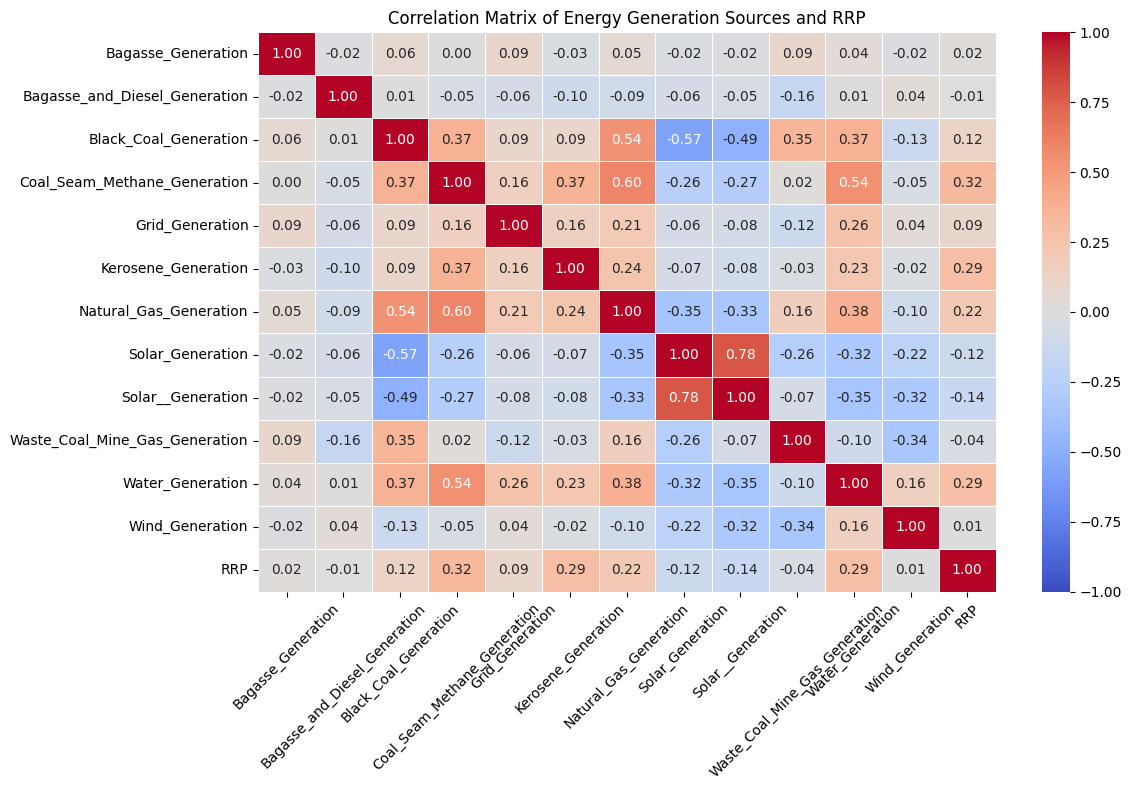

In [74]:
numeric_df = df_scada_price_qld.drop(columns=['Date_Hour', 'REGIONID'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            linewidths=0.5,
            vmin=-1, vmax=1)  # Ensures scale is -1 to 1

plt.title("Correlation Matrix of Energy Generation Sources and RRP")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [86]:
df_scada_price_qld.to_csv('scada_price_inqld_joined_df.csv')

In [62]:
df_scada_price_qld = pd.read_csv('scada_price_inqld_joined_df.csv', index_col=False)
del df_scada_price_qld['Unnamed: 0']
del df_scada_price_qld['REGIONID']

In [14]:
df_scada_price_qld = df_scada_price_qld.fillna(0)

In [16]:
df_scada_price_qld['Date_Hour'] = pd.to_datetime(df_scada_price_qld['Date_Hour'])

# Extract only the date part (no time)
df_scada_price_qld['Date'] = df_scada_price_qld['Date_Hour'].dt.date

# List of all columns to sum except 'RRP'
cols_to_sum = df_scada_price_qld.columns.difference(['Date_Hour', 'Date', 'RRP'])

# Group by date and aggregate
df_scada_price_daily = df_scada_price_qld.groupby('Date').agg({
    **{col: 'sum' for col in cols_to_sum},
    'RRP': 'mean'
}).reset_index()

In [17]:
df_scada_price_daily

,Date,Bagasse_Generation,Bagasse_and_Diesel_Generation,Black_Coal_Generation,Coal_Seam_Methane_Generation,Grid_Generation,Kerosene_Generation,Natural_Gas_Generation,Solar_Generation,Solar__Generation,Waste_Coal_Mine_Gas_Generation,Water_Generation,Wind_Generation,RRP
0,2019-01-01,0.000000,0.0,1.671688e+06,9777.42724,0.00000,0.0,106910.81036,58429.873176,9128.30772,20623.012628,43968.98500,32223.88735,72.285957
1,2019-01-02,0.000000,0.0,1.732890e+06,16616.72722,0.00000,0.0,164253.57687,60563.927264,8681.22181,21994.243772,44116.09250,23157.98010,82.599959
2,2019-01-03,0.000000,0.0,1.759565e+06,20776.63876,0.00000,0.0,140623.19509,60621.532980,8791.61303,22191.593898,44146.07000,9750.36004,89.223163
3,2019-01-04,0.000000,0.0,1.761438e+06,76513.61449,0.00000,0.0,160314.01217,53621.279434,6751.24068,22490.500135,42617.66250,9406.85359,86.215225
4,2019-01-05,0.000000,0.0,1.733227e+06,64082.86128,0.00000,0.0,115391.63126,55288.063115,7240.16585,22888.562831,41272.19250,8315.69346,79.564701
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2187,2024-12-27,1308.599999,0.0,1.365006e+06,7718.84632,8691.56549,0.0,106270.70291,250078.820149,8702.69731,13777.324030,58224.98921,85714.32387,49.935628
2188,2024-12-28,4116.399984,0.0,1.421582e+06,20766.24693,8223.89139,0.0,113434.15102,236354.863453,7693.64305,14134.877948,59023.07672,35921.72648,68.328218
2189,2024-12-29,4038.100017,0.0,1.422846e+06,5415.16569,5887.77850,0.0,110527.28000,242358.000046,8061.87471,12701.551997,59689.44668,51134.07099,42.764766
2190,2024-12-30,4547.100021,0.0,1.479513e+06,58.00896,6682.86862,0.0,124194.72030,207360.219264,4180.79915,13182.236973,48623.01935,71966.49506,80.096709


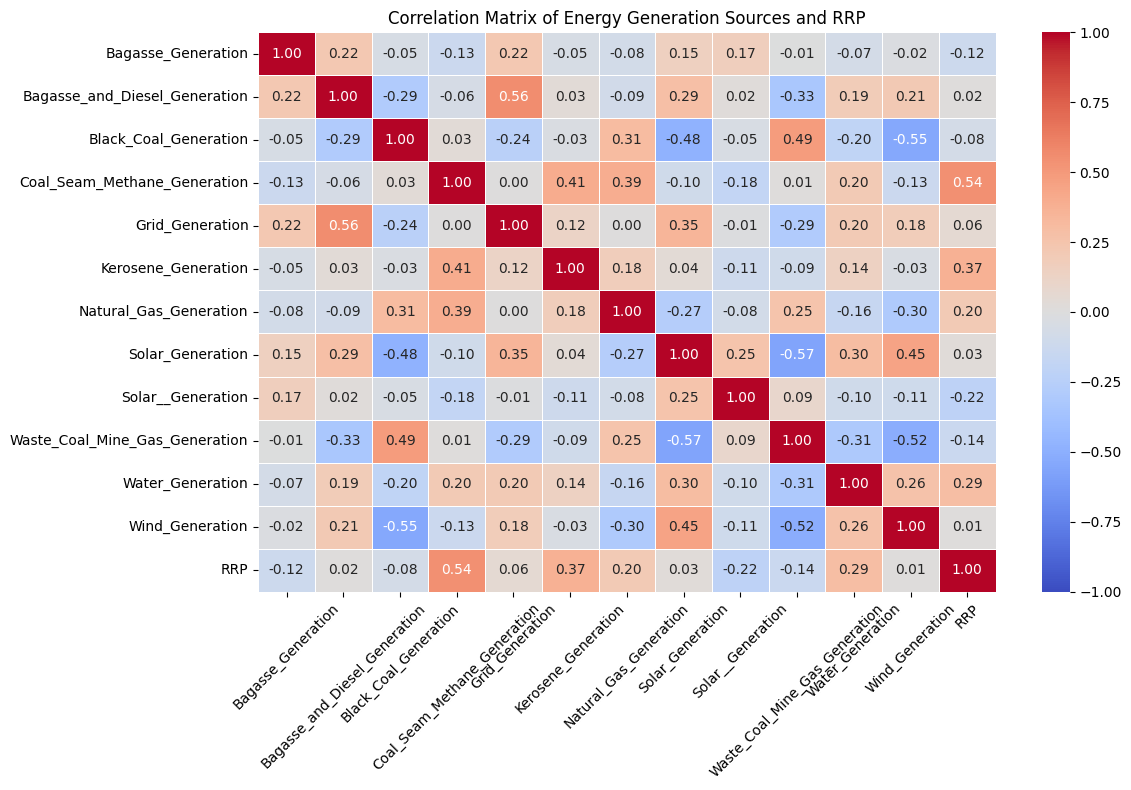

In [19]:
numeric_df = df_scada_price_daily.drop(columns=['Date'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            linewidths=0.5,
            vmin=-1, vmax=1)  # Ensures scale is -1 to 1

plt.title("Correlation Matrix of Energy Generation Sources and RRP")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
df_demand_qld = df_demand[df_demand['REGIONID'] == 'QLD1'] 

In [25]:
del df_demand_qld['REGIONID']

In [28]:
df_demand_qld['Date_Hour'] = pd.to_datetime(df_demand_qld['Date_Hour'])

# Extract only the date part (no time)
df_demand_qld['Date'] = df_demand_qld['Date_Hour'].dt.date

/var/folders/b6/bmslj24d11n41826_8m7yb400000gn/T/ipykernel_3876/110023209.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_demand_qld['Date_Hour'] = pd.to_datetime(df_demand_qld['Date_Hour'])
/var/folders/b6/bmslj24d11n41826_8m7yb400000gn/T/ipykernel_3876/110023209.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_demand_qld['Date'] = df_demand_qld['Date_Hour'].dt.date


In [30]:
del df_demand_qld['Date_Hour']

In [32]:
df_joined = df_scada_price_daily.merge(df_demand_qld, on = 'Date')

In [34]:
df_joined.head()

,Date,Bagasse_Generation,Bagasse_and_Diesel_Generation,Black_Coal_Generation,Coal_Seam_Methane_Generation,Grid_Generation,Kerosene_Generation,Natural_Gas_Generation,Solar_Generation,Solar__Generation,Waste_Coal_Mine_Gas_Generation,Water_Generation,Wind_Generation,RRP,RESDEMAND
0,2019-01-01,0.0,0.0,1.671688e+06,9777.42724,0.0,0.0,106910.81036,58429.873176,9128.30772,20623.012628,43968.9850,32223.88735,72.285957,115674373.0
1,2019-01-02,0.0,0.0,1.732890e+06,16616.72722,0.0,0.0,164253.57687,60563.927264,8681.22181,21994.243772,44116.0925,23157.98010,82.599959,123473992.0
2,2019-01-03,0.0,0.0,1.759565e+06,20776.63876,0.0,0.0,140623.19509,60621.532980,8791.61303,22191.593898,44146.0700,9750.36004,89.223163,122851746.0
3,2019-01-04,0.0,0.0,1.761438e+06,76513.61449,0.0,0.0,160314.01217,53621.279434,6751.24068,22490.500135,42617.6625,9406.85359,86.215225,122740848.0
4,2019-01-05,0.0,0.0,1.733227e+06,64082.86128,0.0,0.0,115391.63126,55288.063115,7240.16585,22888.562831,41272.1925,8315.69346,79.564701,118949941.0


# data for model check and visualisation

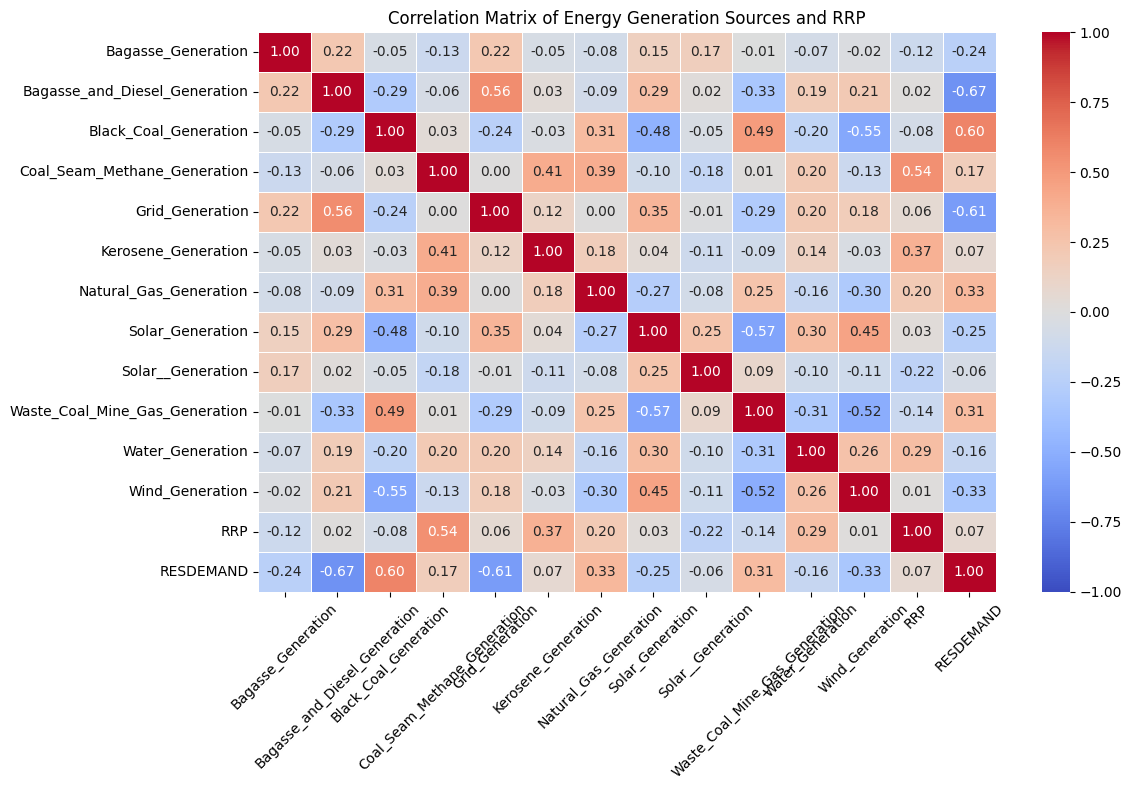

In [35]:
numeric_df = df_joined.drop(columns=['Date'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            linewidths=0.5,
            vmin=-1, vmax=1)  # Ensures scale is -1 to 1

plt.title("Correlation Matrix of Energy Generation Sources and RRP")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [40]:
df_energy_demand = df_joined
df_energy_demand.describe().T

,count,mean,std,min,25%,50%,75%,max
Bagasse_Generation,2192.0,1.243091e+03,1.739601e+03,0.000000e+00,0.000000e+00,0.000000e+00,3.094175e+03,6.032900e+03
Bagasse_and_Diesel_Generation,2192.0,1.221560e+02,5.577364e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.883200e+03
Black_Coal_Generation,2192.0,1.485963e+06,1.410964e+05,1.099448e+06,1.389032e+06,1.477978e+06,1.581852e+06,1.882700e+06
Coal_Seam_Methane_Generation,2192.0,2.705091e+04,2.238510e+04,0.000000e+00,1.079695e+04,2.173614e+04,3.825086e+04,1.518029e+05
Grid_Generation,2192.0,2.831157e+02,1.191162e+03,0.000000e+00,0.000000e+00,0.000000e+00,4.023250e+01,1.118492e+04
Kerosene_Generation,2192.0,1.118920e+03,3.454856e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.554049e+04
Natural_Gas_Generation,2192.0,1.350248e+05,5.941925e+04,0.000000e+00,8.938374e+04,1.258379e+05,1.671838e+05,3.526786e+05
Solar_Generation,2192.0,1.297911e+05,5.905633e+04,1.132300e+04,8.778977e+04,1.180223e+05,1.676487e+05,3.299033e+05
Solar__Generation,2192.0,6.944342e+03,2.192505e+03,0.000000e+00,5.794512e+03,7.442855e+03,8.585097e+03,1.073660e+04
Waste_Coal_Mine_Gas_Generation,2192.0,1.871820e+04,4.574566e+03,3.011719e+03,1.546385e+04,1.823347e+04,2.222482e+04,2.802721e+04


In [63]:
df_scada_price_qld = df_scada_price_qld.fillna(0)
df_scada_price_qld.describe().T

,count,mean,std,min,25%,50%,75%,max
Bagasse_Generation,52608.0,51.795475,77.994370,0.00000,0.000000,0.000000,132.500000,295.199999
Bagasse_and_Diesel_Generation,52608.0,5.089834,23.627902,0.00000,0.000000,0.000000,0.000000,122.400000
Black_Coal_Generation,52608.0,61915.110042,8727.336776,20935.42154,56764.108790,62595.842925,67942.348552,89189.176560
Coal_Seam_Methane_Generation,52608.0,1127.121365,2071.345668,0.00000,2.417040,4.592400,1443.446225,12551.836070
Grid_Generation,52608.0,11.796486,109.523687,0.00000,0.000000,0.000000,0.010000,3772.997050
Kerosene_Generation,52608.0,46.621650,306.800392,0.00000,0.000000,0.000000,0.000000,4696.714490
Natural_Gas_Generation,52608.0,5626.034816,4083.536997,0.00000,2076.821513,4540.211660,8191.699312,21697.983450
Solar_Generation,52608.0,5407.962011,7197.027463,0.00000,2.319600,261.727165,10323.640742,33331.341792
Solar__Generation,52608.0,289.347576,402.172157,0.00000,0.000000,6.730095,575.825140,1321.529310
Waste_Coal_Mine_Gas_Generation,52608.0,779.925166,202.960473,0.00000,641.367195,767.754380,927.092180,1209.949963


In [65]:
df_scada_price_qld

,Date_Hour,Bagasse_Generation,Bagasse_and_Diesel_Generation,Black_Coal_Generation,Coal_Seam_Methane_Generation,Grid_Generation,Kerosene_Generation,Natural_Gas_Generation,Solar_Generation,Solar__Generation,Waste_Coal_Mine_Gas_Generation,Water_Generation,Wind_Generation,RRP
0,2019-01-01 00:00:00,0.0,0.0,62858.98551,0.00000,0.00000,0.0,3975.97976,6.171,0.0,746.831214,1681.93500,1085.28027,64.605948
1,2019-01-01 01:00:00,0.0,0.0,67183.38066,0.00000,0.00000,0.0,4304.76559,6.732,0.0,669.637499,1834.12000,1416.38041,66.544864
2,2019-01-01 02:00:00,0.0,0.0,65502.50779,0.00000,0.00000,0.0,4109.34554,6.732,0.0,896.243756,1829.31000,1539.30137,61.140174
3,2019-01-01 03:00:00,0.0,0.0,63496.45470,0.00000,0.00000,0.0,4091.15064,6.732,0.0,930.731348,1829.77500,1581.81376,52.883149
4,2019-01-01 04:00:00,0.0,0.0,61761.28180,0.00000,0.00000,0.0,4096.64811,6.732,0.0,902.593736,1832.42250,1613.19730,49.505579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52603,2024-12-31 19:00:00,137.8,0.0,70423.59441,2.41704,1754.75433,0.0,7276.27845,1.400,0.0,565.648998,7011.20237,2760.38489,110.548923
52604,2024-12-31 20:00:00,142.2,0.0,67278.17977,2.41704,873.97689,0.0,7327.86777,0.000,0.0,576.388997,6656.20739,3791.81233,88.832243
52605,2024-12-31 21:00:00,147.6,0.0,67530.42504,2.41704,172.49184,0.0,6406.25727,0.000,0.0,578.700999,5736.09491,5619.54925,104.790372
52606,2024-12-31 22:00:00,150.0,0.0,64839.12167,2.41704,84.83913,0.0,4710.58082,0.000,0.0,567.865998,4443.00246,5788.56026,119.809608


In [66]:
df_scada_price_qld['Date_Hour'] = pd.to_datetime(df_scada_price_qld['Date_Hour'])
df_scada_price_qld['Hour'] = df_scada_price_qld['Date_Hour'].dt.hour
df_scada_price_qld['Month'] = df_scada_price_qld['Date_Hour'].dt.month
df_scada_price_qld['WeekDay'] = df_scada_price_qld['Date_Hour'].dt.weekday
df_scada_price_qld['Year'] = df_scada_price_qld['Date_Hour'].dt.year

In [68]:
df_scada_price_qld.head()

,Bagasse_Generation,Bagasse_and_Diesel_Generation,Black_Coal_Generation,Coal_Seam_Methane_Generation,Grid_Generation,Kerosene_Generation,Natural_Gas_Generation,Solar_Generation,Solar__Generation,Waste_Coal_Mine_Gas_Generation,Water_Generation,Wind_Generation,RRP,Hour,Month,WeekDay,Year
Date_Hour,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,0.0,0.0,62858.98551,0.0,0.0,0.0,3975.97976,6.171,0.0,746.831214,1681.9350,1085.28027,64.605948,0,1,1,2019
2019-01-01 01:00:00,0.0,0.0,67183.38066,0.0,0.0,0.0,4304.76559,6.732,0.0,669.637499,1834.1200,1416.38041,66.544864,1,1,1,2019
2019-01-01 02:00:00,0.0,0.0,65502.50779,0.0,0.0,0.0,4109.34554,6.732,0.0,896.243756,1829.3100,1539.30137,61.140174,2,1,1,2019
2019-01-01 03:00:00,0.0,0.0,63496.45470,0.0,0.0,0.0,4091.15064,6.732,0.0,930.731348,1829.7750,1581.81376,52.883149,3,1,1,2019
2019-01-01 04:00:00,0.0,0.0,61761.28180,0.0,0.0,0.0,4096.64811,6.732,0.0,902.593736,1832.4225,1613.19730,49.505579,4,1,1,2019


In [71]:
df_energy_demand['weekday'] = df_energy_demand.index.map(lambda x : x.weekday())
df_energy_demand['month'] = df_energy_demand.index.map(lambda x : x.month)
df_energy_demand['year'] = df_energy_demand.index.map(lambda x: x.year)

In [67]:
df_energy_demand = df_energy_demand.set_index('Date')
df_scada_price_qld = df_scada_price_qld.set_index('Date_Hour')

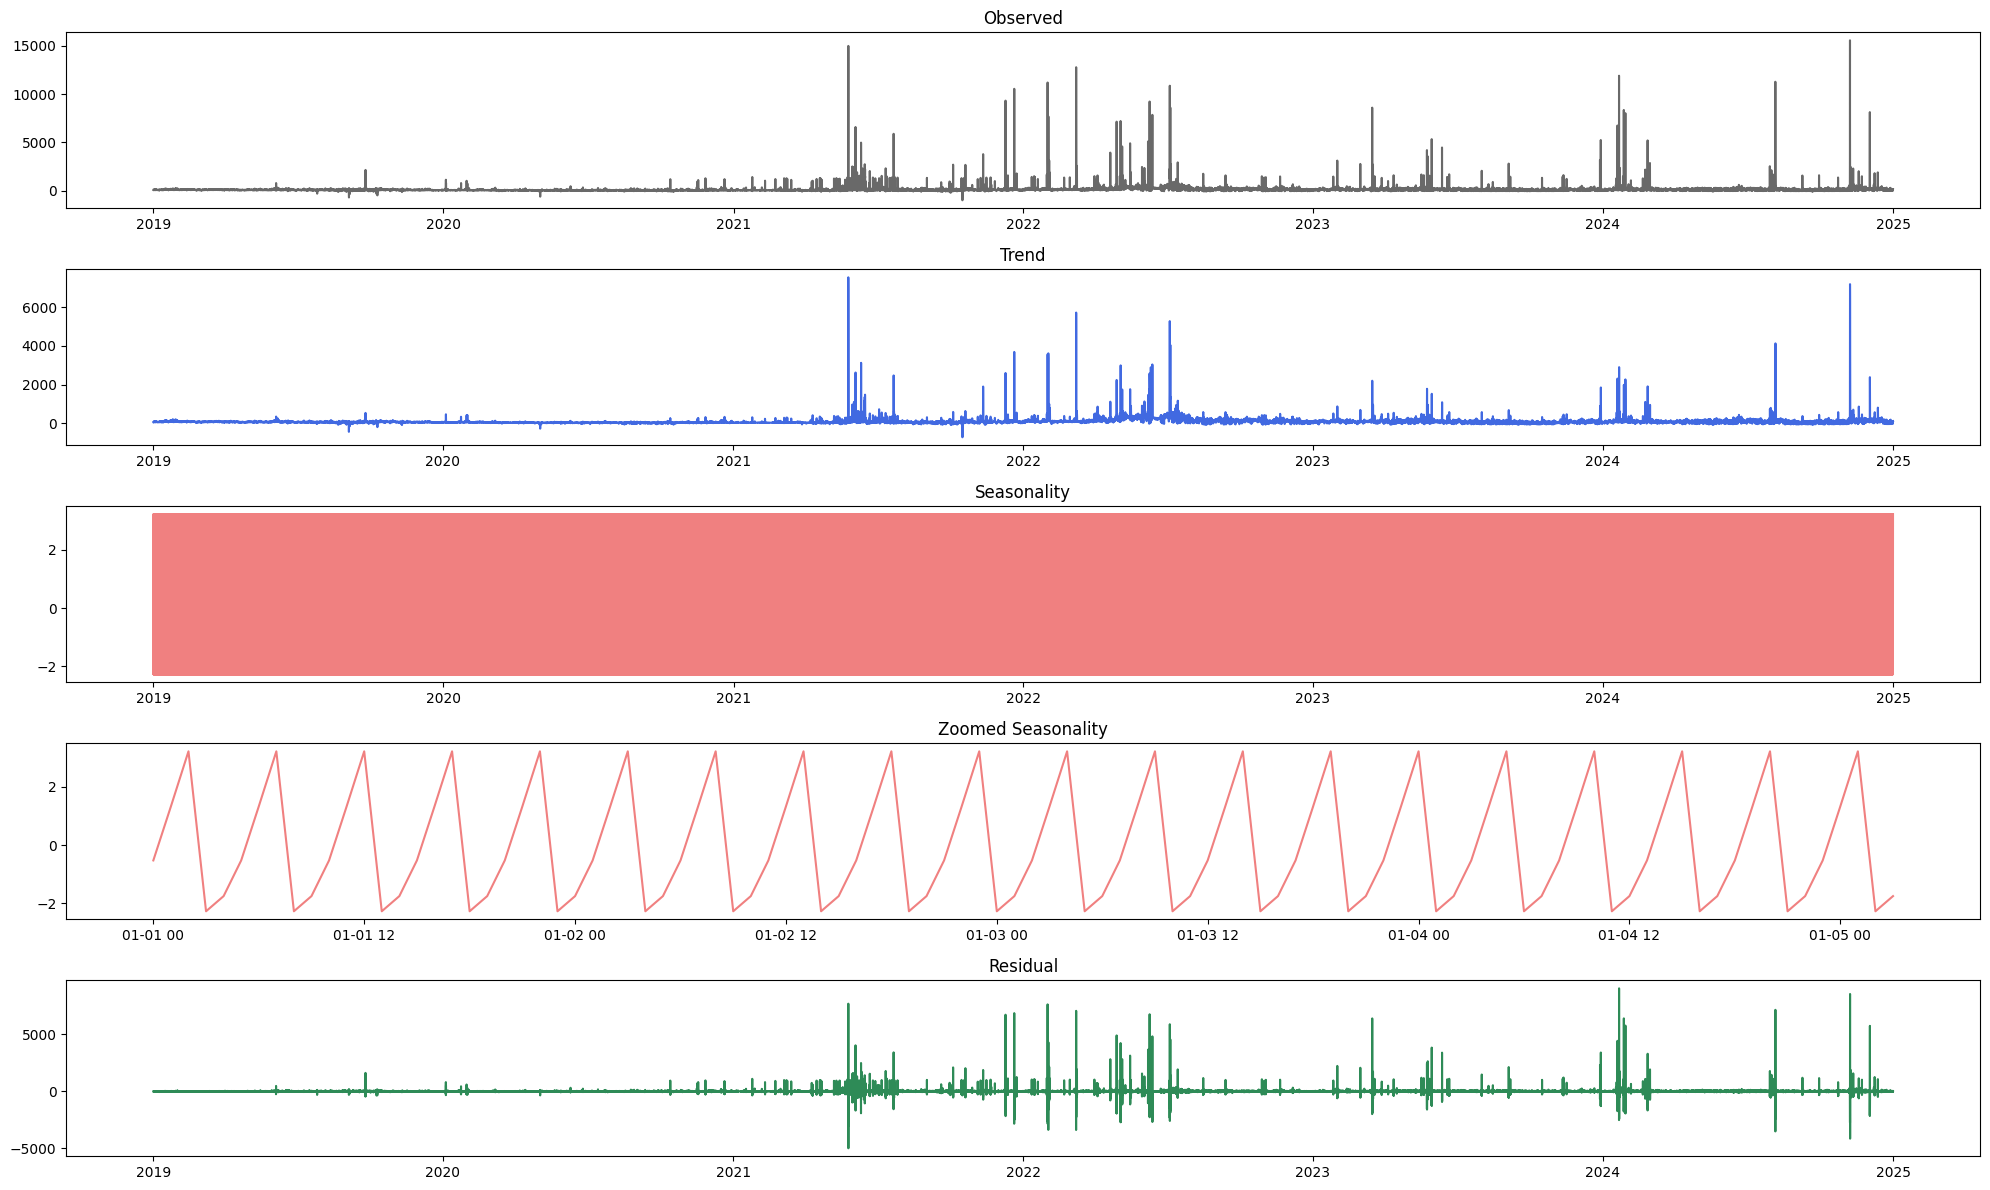

In [72]:
fig, axes = plt.subplots(5, 1, figsize=(20, 12))
decom_data = df_scada_price_qld[['RRP']].copy()

decompose_result = seasonal_decompose(decom_data, period =5, model='additive')

observed    = decompose_result.observed
trend    = decompose_result.trend
seasonal = decompose_result.seasonal
residual = decompose_result.resid

axes[0].plot(observed, color='dimgrey')
axes[0].set_title('Observed')
axes[1].plot(trend, color='royalblue')
axes[1].set_title('Trend')
axes[2].plot(seasonal, color='lightcoral')
axes[2].set_title('Seasonality')
axes[3].plot(seasonal[:100], color='lightcoral')
axes[3].set_title('Zoomed Seasonality')
axes[4].plot(residual, color='seagreen')
axes[4].set_title('Residual')

fig.tight_layout()
plt.show()

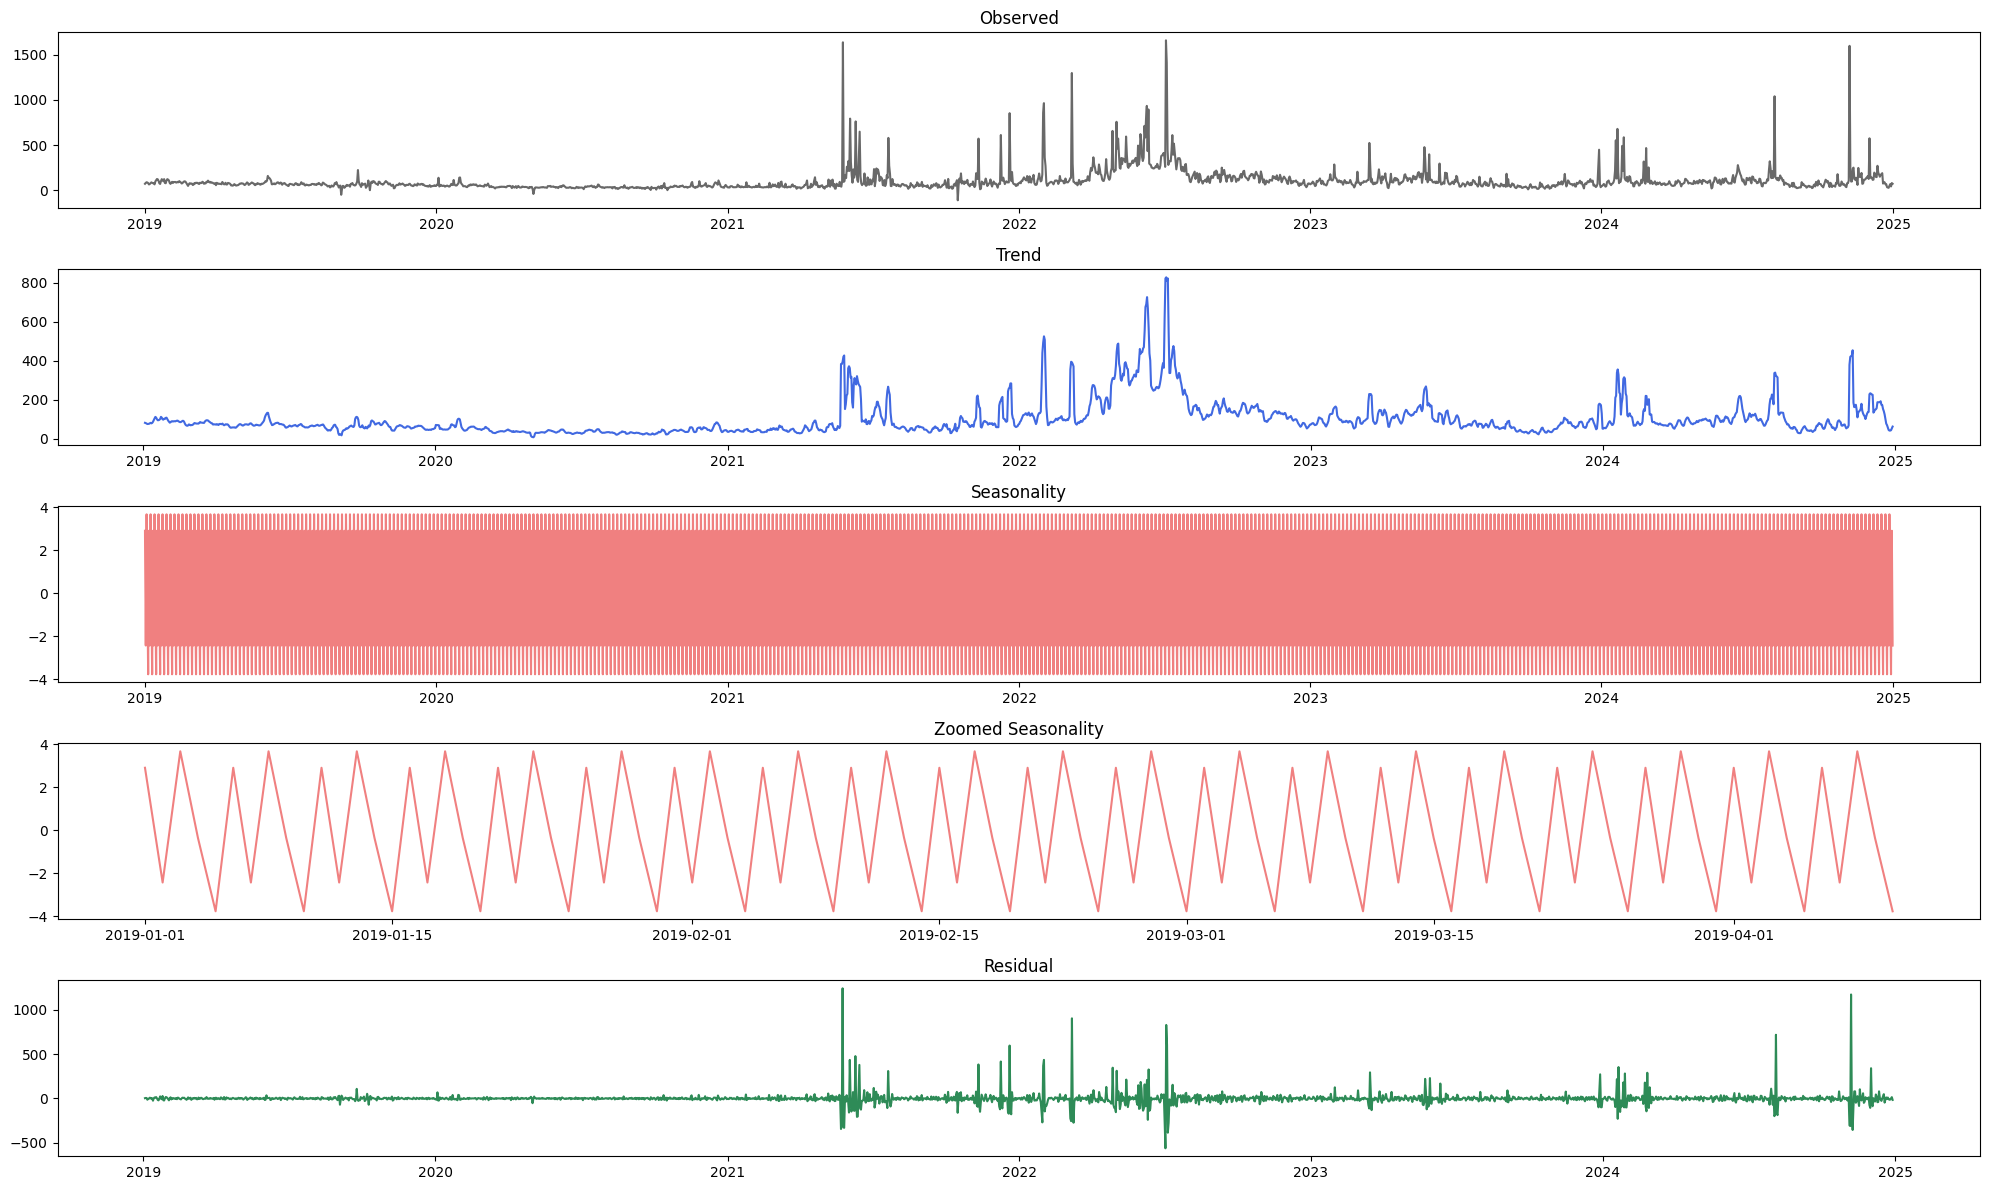

In [73]:
fig, axes = plt.subplots(5, 1, figsize=(20, 12))
decom_data = df_energy_demand[['RRP']].copy()

decompose_result = seasonal_decompose(decom_data, period =5, model='additive')

observed    = decompose_result.observed
trend    = decompose_result.trend
seasonal = decompose_result.seasonal
residual = decompose_result.resid

axes[0].plot(observed, color='dimgrey')
axes[0].set_title('Observed')
axes[1].plot(trend, color='royalblue')
axes[1].set_title('Trend')
axes[2].plot(seasonal, color='lightcoral')
axes[2].set_title('Seasonality')
axes[3].plot(seasonal[:100], color='lightcoral')
axes[3].set_title('Zoomed Seasonality')
axes[4].plot(residual, color='seagreen')
axes[4].set_title('Residual')

fig.tight_layout()
plt.show()

In [75]:
result = adfuller(df_scada_price_qld[['RRP']])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: -18.575142449249967
p-value: 2.0806344986993726e-30
Critical Values: {'1%': -3.430474426717326, '5%': -2.861594994112659, '10%': -2.5667992715370773}


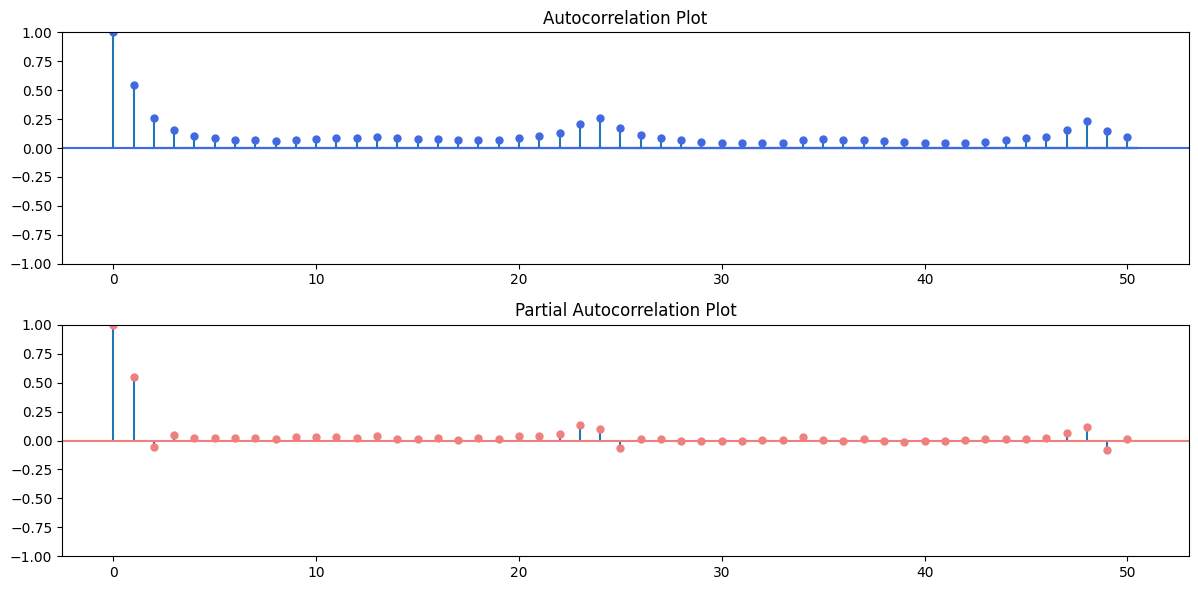

In [78]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6))
plot_acf(df_scada_price_qld['RRP'], lags=50, ax=ax[0], color='royalblue')
ax[0].set_title('Autocorrelation Plot')
plot_pacf(df_scada_price_qld['RRP'], lags=50, ax=ax[1], color='lightcoral')
ax[1].set_title('Partial Autocorrelation Plot')
plt.tight_layout()
plt.show()

In [79]:
result = adfuller(df_energy_demand[['RRP']])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: -3.4051390253238965
p-value: 0.010784925149902093
Critical Values: {'1%': -3.4333740509447717, '5%': -2.8628759187993382, '10%': -2.567481176655697}


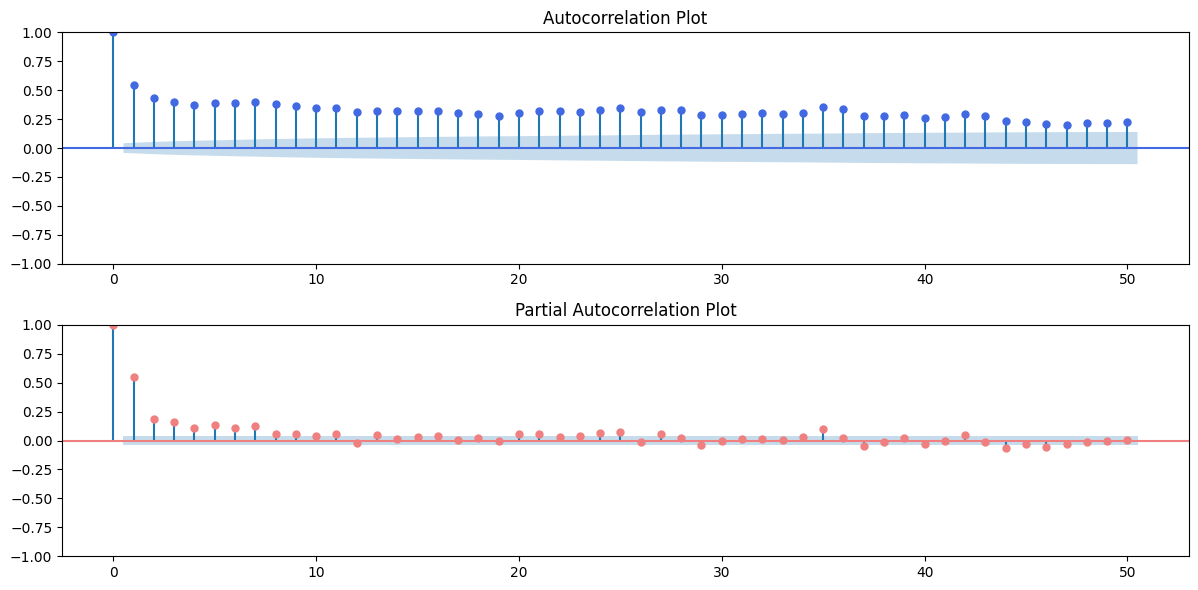

In [80]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6))
plot_acf(df_energy_demand['RRP'], lags=50, ax=ax[0], color='royalblue')
ax[0].set_title('Autocorrelation Plot')
plot_pacf(df_energy_demand['RRP'], lags=50, ax=ax[1], color='lightcoral')
ax[1].set_title('Partial Autocorrelation Plot')
plt.tight_layout()
plt.show()

# dimensionality reduction and train-test split for scada-demand-price data

In [126]:
X = df_scada_price_qld.drop(['RRP'], axis = 1)
y = df_scada_price_qld[['RRP']]

In [127]:
def apply_PCA(X_input, cum_variance, if_apply):
    
    if if_apply:
    
        pca = PCA(n_components = cum_variance)
        # make pipeline to first standardize then apply PCA on data
        scaler_pca = make_pipeline(MinMaxScaler(), pca)
        X_pca = scaler_pca.fit(X_input).transform(X_input)

        return X_pca
    
    else:
        
        return np.array(X_input)

In [128]:
params_pca = {'cum_variance' : 0.8, 'if_apply' : True }
X_pca = apply_PCA(X, **params_pca)
X_pca.shape

(52608, 6)

In [129]:
def windowing(X_input,y_input, history_size):
    
    data = []
    labels = []
    for i in range(history_size, len(y_input)):
        data.append(X_input[i - history_size : i, :])
        labels.append(y_input[i])
        
    return np.array(data), np.array(labels).reshape(-1,1)

In [130]:
train_cutoff = int(0.8*X_pca.shape[0])
val_cutoff   = int(0.9*X_pca.shape[0])

scaler_y = MinMaxScaler()
scaler_y.fit(y[:train_cutoff])
y_norm = scaler_y.transform(y)

In [131]:
hist_size= 24
data_norm = np.concatenate((X_pca,y_norm), axis = 1)

X_train, y_train = windowing(data_norm[:train_cutoff,:],data_norm[:train_cutoff,-1], hist_size)
X_val, y_val     = windowing(data_norm[train_cutoff :val_cutoff,:],data_norm[train_cutoff:val_cutoff,-1], hist_size)
X_test, y_test   = windowing(data_norm[val_cutoff :,:],data_norm[val_cutoff:,-1], hist_size)

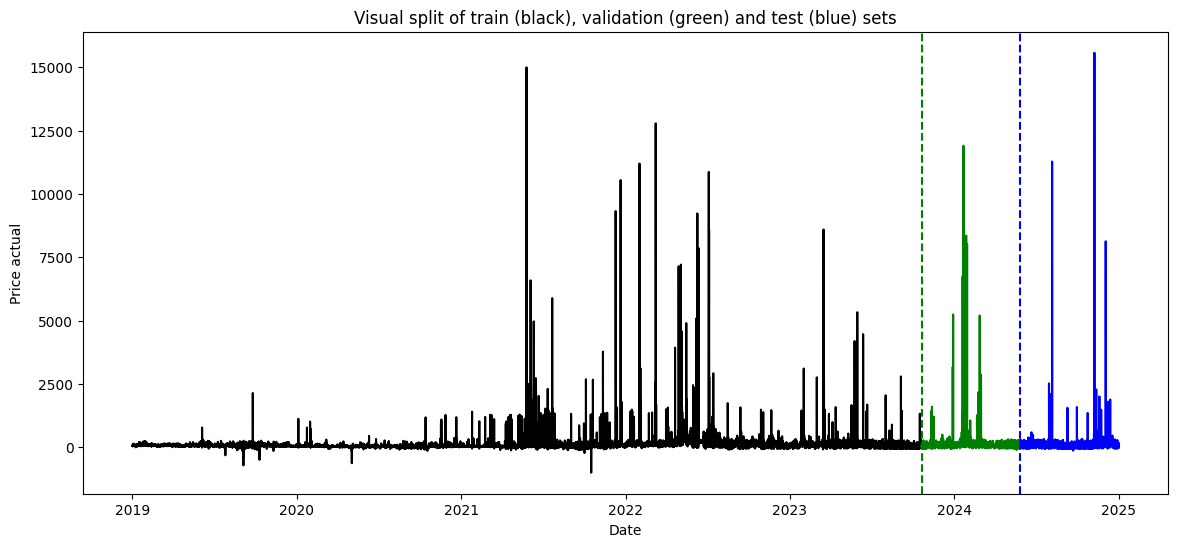

In [132]:
fig, axes = plt.subplots(figsize = (14,6))
axes.plot(df_scada_price_qld['RRP'].iloc[:train_cutoff], color = 'black')
axes.plot(df_scada_price_qld['RRP'].iloc[train_cutoff + 1 : val_cutoff], color = 'green')
axes.plot(df_scada_price_qld['RRP'].iloc[val_cutoff + 1 :], color = 'blue')
axes.axvline(x=df_scada_price_qld.index[train_cutoff], color='green', linestyle='--')
axes.axvline(x=df_scada_price_qld.index[val_cutoff], color='blue', linestyle='--')
axes.set_title('Visual split of train (black), validation (green) and test (blue) sets')
axes.set_xlabel('Date')
axes.set_ylabel('Price actual')
plt.show()

In [133]:
df_energy_demand.to_csv('demand_price_scada_daily.csv')
df_scada_price_qld.to_csv('non_demand_price_scada_hourly.csv')

# forcasting

## xgboost

In [158]:
def reshaping(X):
    
    reshaped_x = X.reshape(-1 , X.shape[1] * X.shape[2])
    return reshaped_x

X_train_xgb = reshaping(X_train)
X_val_xgb   = reshaping(X_val)
X_test_xgb  = reshaping(X_test)

In [159]:
xgb_model = xgb.XGBRegressor()
xgb_model.fit(X_train_xgb, y_train,
               eval_set=[(X_train_xgb, y_train), (X_val_xgb, y_val)],     
               eval_metric='mae',
               early_stopping_rounds=8,
               verbose=False) 

TypeError: fit() got an unexpected keyword argument 'eval_metric'

## GRU

In [136]:
def base_model_gru():
    
    model = Sequential()
    model.add(GRU(units=32, return_sequences=True, activation="relu", input_shape=X_train.shape[-2:]))
    model.add(Flatten())
    model.add(Dense(units=128, activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(1))
    
    return model

gru_model = base_model_gru()

In [137]:
# inputs for DL models
epoch = 100
batch_size = 64
steps_per_epoch = len(X_train) // batch_size
cyclic_lr = tfa.optimizers.CyclicalLearningRate(initial_learning_rate=1e-04,
                                                maximal_learning_rate=1e-02,
                                                scale_fn=lambda x: 1/(2**(x-1)),
                                                step_size=6 * steps_per_epoch)

callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8)
optimizer = Adam(learning_rate=cyclic_lr, amsgrad=True)

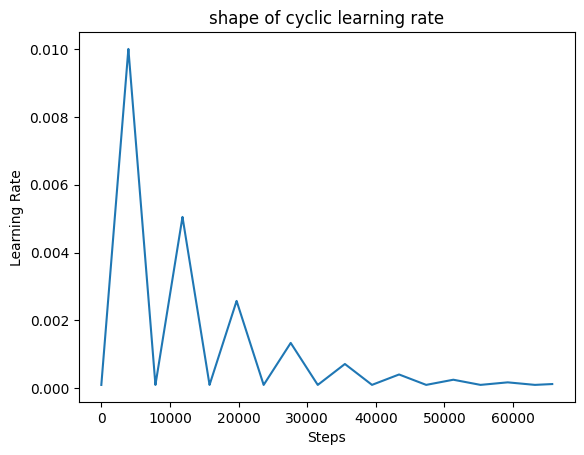

In [138]:
step = np.arange(0, epoch * steps_per_epoch)
lr = cyclic_lr(step)
plt.plot(step, lr)
plt.xlabel("Steps")
plt.ylabel("Learning Rate")
plt.title("shape of cyclic learning rate")
plt.show()

In [139]:
gru_model.compile(optimizer = optimizer , loss = 'mean_absolute_error')
history = gru_model.fit(X_train, y_train, validation_data = (X_val, y_val), epochs = epoch, 
                   batch_size = batch_size, callbacks=[callback])

Epoch 1/100


/Users/khang/anaconda3/envs/my_env/lib/python3.8/site-packages/keras/src/saving/serialization_lib.py:394: UserWarning: The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized:                                                 scale_fn=lambda x: 1/(2**(x-1)),

  return {key: serialize_keras_object(value) for key, value in obj.items()}


658/658 [==============================] - 3s 4ms/step - loss: 0.0103 - val_loss: 0.0035
Epoch 2/100
658/658 [==============================] - 2s 4ms/step - loss: 0.0030 - val_loss: 0.0035
Epoch 3/100
658/658 [==============================] - 2s 4ms/step - loss: 0.0028 - val_loss: 0.0034
Epoch 4/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0028 - val_loss: 0.0034
Epoch 5/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0028 - val_loss: 0.0040
Epoch 6/100
658/658 [==============================] - 2s 4ms/step - loss: 0.0029 - val_loss: 0.0039
Epoch 7/100
658/658 [==============================] - 2s 4ms/step - loss: 0.0028 - val_loss: 0.0031
Epoch 8/100
658/658 [==============================] - 2s 4ms/step - loss: 0.0026 - val_loss: 0.0030
Epoch 9/100
658/658 [==============================] - 2s 4ms/step - loss: 0.0025 - val_loss: 0.0030
Epoch 10/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0024 - val_loss: 0.0028
E

In [140]:
def plot_results(y_pred_actual, y_test_inv, model, model_name):
    fig, ax = plt.subplots(2, 1, figsize=(12, 6))
    
    ax[0].plot(y_pred_actual[:1000])
    ax[0].plot(y_test_inv[:1000])
    ax[0].legend(['prediction', 'actual'], loc='upper left')
    ax[0].set_title(f'Prediction vs actual price for 1000 observation in test set ({model_name})')
    ax[0].set_xlabel('Observation')
    ax[0].set_ylabel('Price')
    
    if model != 'hybrid':
    
        if model_name == 'XGBoost':

            train_mae = model.evals_result()['validation_0']['mae']
            val_mae = model.evals_result()['validation_1']['mae']
            ax[1].plot(train_mae, label='Training MAE')
            ax[1].plot(val_mae, label='Validation MAE')

        else:

            ax[1].plot(history.history['loss'], label='Training Loss')
            ax[1].plot(history.history['val_loss'], label='Validation Loss')

        ax[1].legend()
        ax[1].set_title(f'Training and validation MAE ({model_name})')
        ax[1].set_xlabel('Iteration/Epochs')
        ax[1].set_ylabel('MAE')    
        
    fig.tight_layout()
    plt.show()

164/164 [==============================] - 0s 717us/step


---------------------------------------------------
GRU MAE for test set : 0.004
---------------------------------------------------



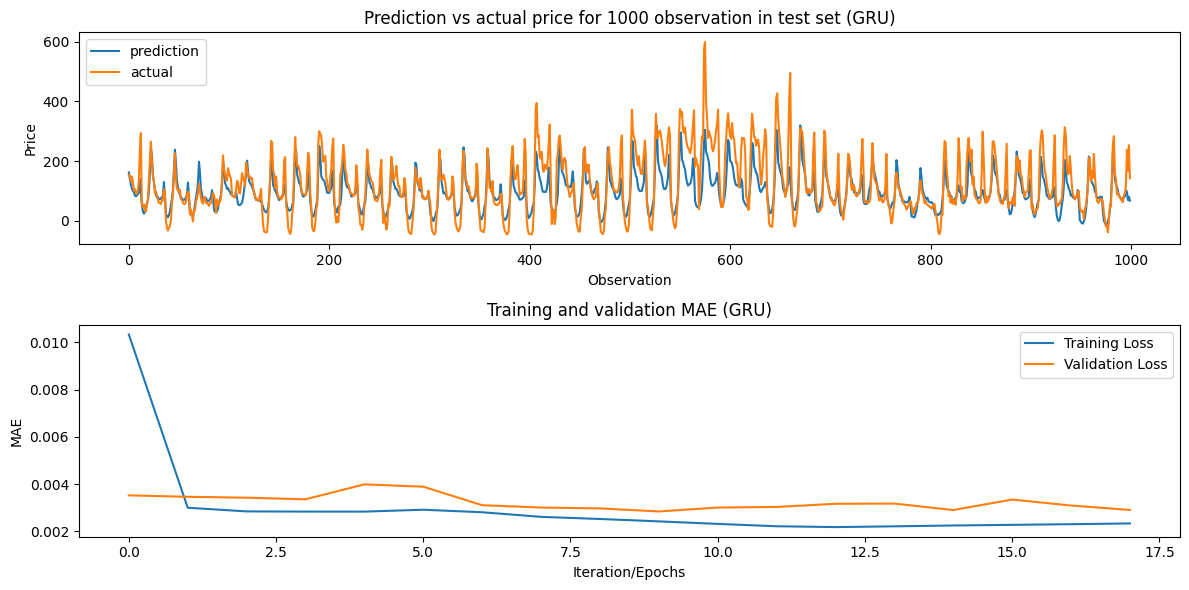

In [141]:
y_pred = gru_model.predict(X_test)
y_pred_actual = scaler_y.inverse_transform(y_pred.reshape(-1,1))
y_test_inv = scaler_y.inverse_transform(y_test)
print('')
print('')
print('---------------------------------------------------')
print(f'GRU MAE for test set : {round(mean_absolute_error(y_pred,y_test),3)}')
print('---------------------------------------------------')
y_pred_actual = scaler_y.inverse_transform(y_pred)
print('')
plot_results(y_pred_actual, y_test_inv, history,'GRU')

## LSTM

In [142]:
def base_model_lstm():

    model = Sequential()
    model.add(LSTM(units = 32, return_sequences = True, activation="relu", input_shape = X_train.shape[-2:]))
    model.add(Flatten())
    model.add(Dense(units=128, activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(1))
    
    return model

lstm_model = base_model_lstm()
lstm_model.compile(optimizer = optimizer , loss = 'mean_absolute_error')
lstm_model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 24, 32)            5120      
                                                                 
 flatten_4 (Flatten)         (None, 768)               0         
                                                                 
 dense_8 (Dense)             (None, 128)               98432     
                                                                 
 dropout_3 (Dropout)         (None, 128)               0         
                                                                 
 dense_9 (Dense)             (None, 1)                 129       
                                                                 
Total params: 103681 (405.00 KB)
Trainable params: 103681 (405.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


/Users/khang/anaconda3/envs/my_env/lib/python3.8/site-packages/keras/src/saving/serialization_lib.py:394: UserWarning: The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized:                                                 scale_fn=lambda x: 1/(2**(x-1)),

  return {key: serialize_keras_object(value) for key, value in obj.items()}


In [143]:
history = lstm_model.fit(X_train, y_train, validation_data = (X_val, y_val), epochs =epoch, 
                   batch_size = batch_size, callbacks=[callback])

Epoch 1/100
658/658 [==============================] - 3s 3ms/step - loss: 0.0115 - val_loss: 0.0036
Epoch 2/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0029 - val_loss: 0.0031
Epoch 3/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0028 - val_loss: 0.0031
Epoch 4/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0028 - val_loss: 0.0031
Epoch 5/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0028 - val_loss: 0.0035
Epoch 6/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 7/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0028 - val_loss: 0.0031
Epoch 8/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0026 - val_loss: 0.0034
Epoch 9/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0025 - val_loss: 0.0030
Epoch 10/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0024 - val_lo

164/164 [==============================] - 0s 765us/step


---------------------------------------------------
LSTM MAE for test set : 0.004
---------------------------------------------------



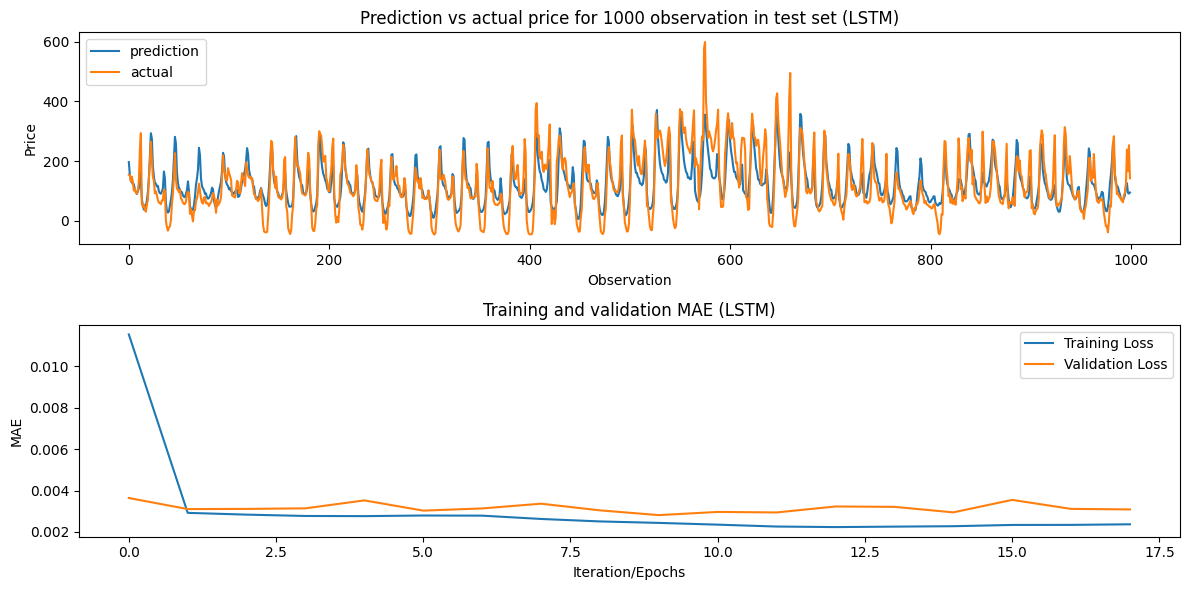

In [144]:
y_pred = lstm_model.predict(X_test)
print('')
print('')
print('---------------------------------------------------')
print(f'LSTM MAE for test set : {round(mean_absolute_error(y_pred,y_test),3)}')
print('---------------------------------------------------')
y_pred_actual = scaler_y.inverse_transform(y_pred)
print('')
plot_results(y_pred_actual, y_test_inv, history,'LSTM')

## CNN + LSTM

In [145]:
def base_model_cnn_lstm():
    
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=X_train.shape[-2:]))
    model.add(LSTM(units = 8, return_sequences = True, activation="relu"))
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dense(1))
    
    return model

cnn_lstm_model = base_model_cnn_lstm()
cnn_lstm_model.compile(optimizer = optimizer , loss = 'mean_absolute_error')
cnn_lstm_model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_1 (Conv1D)           (None, 22, 64)            1408      
                                                                 
 lstm_3 (LSTM)               (None, 22, 8)             2336      
                                                                 
 flatten_5 (Flatten)         (None, 176)               0         
                                                                 
 dense_10 (Dense)            (None, 256)               45312     
                                                                 
 dense_11 (Dense)            (None, 1)                 257       
                                                                 
Total params: 49313 (192.63 KB)
Trainable params: 49313 (192.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


/Users/khang/anaconda3/envs/my_env/lib/python3.8/site-packages/keras/src/saving/serialization_lib.py:394: UserWarning: The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized:                                                 scale_fn=lambda x: 1/(2**(x-1)),

  return {key: serialize_keras_object(value) for key, value in obj.items()}


In [146]:
history = cnn_lstm_model.fit(X_train, y_train, validation_data = (X_val, y_val), epochs = epoch, 
                   batch_size = batch_size, callbacks=[callback])

Epoch 1/100
658/658 [==============================] - 3s 3ms/step - loss: 0.0051 - val_loss: 0.0035
Epoch 2/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0033 - val_loss: 0.0039
Epoch 3/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0030 - val_loss: 0.0030
Epoch 4/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0029 - val_loss: 0.0033
Epoch 5/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0027 - val_loss: 0.0032
Epoch 6/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0027 - val_loss: 0.0030
Epoch 7/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0027 - val_loss: 0.0029
Epoch 8/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0025 - val_loss: 0.0029
Epoch 9/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0024 - val_loss: 0.0031
Epoch 10/100
658/658 [==============================] - 2s 3ms/step - loss: 0.0023 - val_lo

164/164 [==============================] - 0s 632us/step


---------------------------------------------------
CNN-LSTM MAE for test set : 0.004
---------------------------------------------------



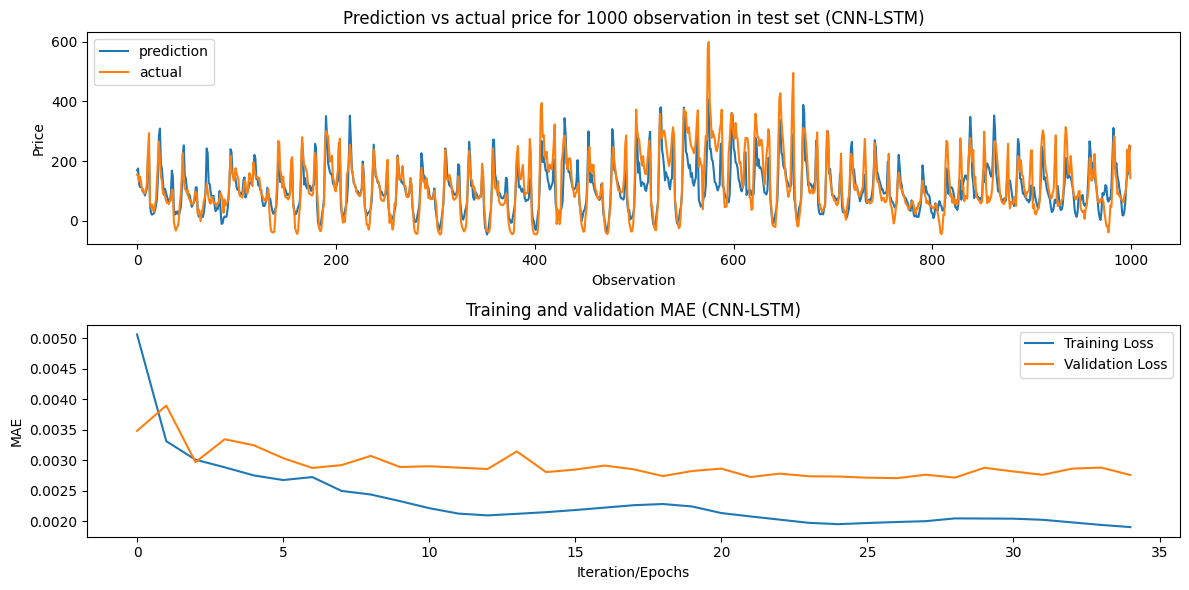

In [147]:
y_pred = cnn_lstm_model.predict(X_test)
print('')
print('')
print('---------------------------------------------------')
print(f'CNN-LSTM MAE for test set : {round(mean_absolute_error(y_pred,y_test),3)}')
print('---------------------------------------------------')
y_pred_actual = scaler_y.inverse_transform(y_pred)
print('')
plot_results(y_pred_actual, y_test_inv, history,'CNN-LSTM')

# forcasting with no PCA

In [160]:
X = df_scada_price_qld.drop(['RRP'], axis = 1)
y = df_scada_price_qld[['RRP']]

In [161]:
train_cutoff = int(0.8*X.shape[0])
val_cutoff   = int(0.9*X.shape[0])

scaler_y = MinMaxScaler()
scaler_y.fit(y[:train_cutoff])
y_norm = scaler_y.transform(y)

In [162]:
hist_size= 24
data_norm = np.concatenate((X,y_norm), axis = 1)

X_train, y_train = windowing(data_norm[:train_cutoff,:],data_norm[:train_cutoff,-1], hist_size)
X_val, y_val     = windowing(data_norm[train_cutoff :val_cutoff,:],data_norm[train_cutoff:val_cutoff,-1], hist_size)
X_test, y_test   = windowing(data_norm[val_cutoff :,:],data_norm[val_cutoff:,-1], hist_size)

In [168]:
def reshaping(X):
    
    reshaped_x = X.reshape(-1 , X.shape[1] * X.shape[2])
    return reshaped_x

X_train_xgb = reshaping(X_train)
X_val_xgb   = reshaping(X_val)
X_test_xgb  = reshaping(X_test)

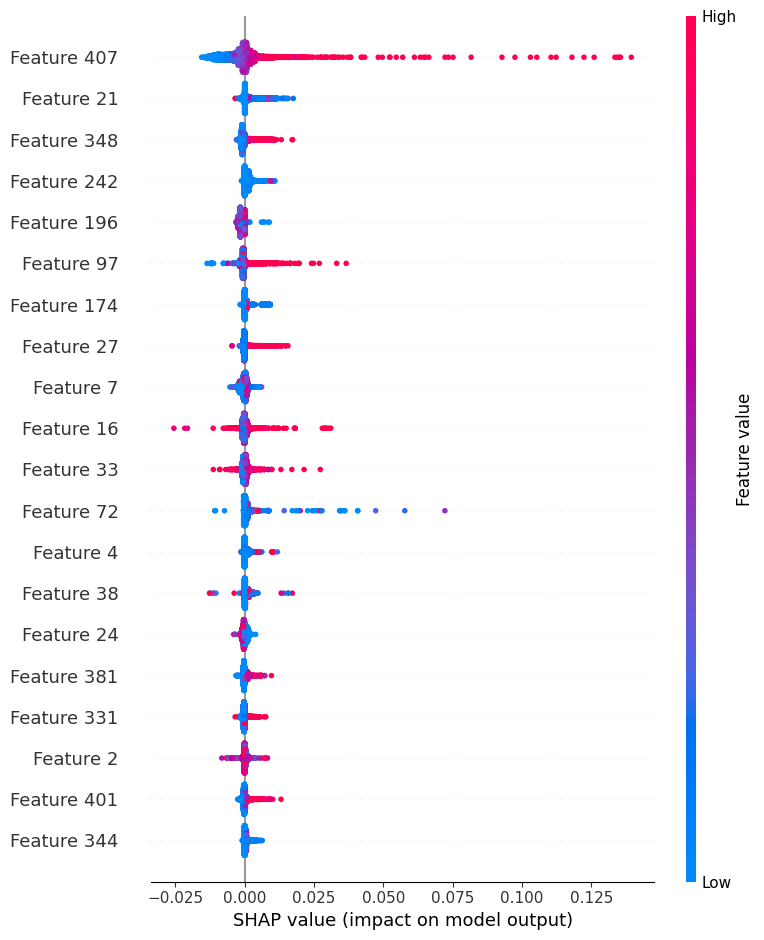

In [169]:
model = xgb.XGBRegressor(objective="reg:squarederror", eval_metric="rmse")
model.fit(X_train_xgb, y_train)

# Step 3: Make predictions
y_pred = model.predict(X_test_xgb)

# Step 4: SHAP Explanation
explainer = shap.Explainer(model, X_train_xgb)  # You can use X_val here as well, depending on your preference
shap_values = explainer(X_test_xgb)

# Step 5: Plot SHAP values for a summary plot
shap.summary_plot(shap_values, X_test_xgb)

# Step 6: (Optional) SHAP values for a single prediction
# If you want to see the SHAP values for a specific instance
instance_idx = 0  # Choose an index in the test set (e.g., the first instance)
shap.initjs()
shap.force_plot(shap_values[instance_idx])

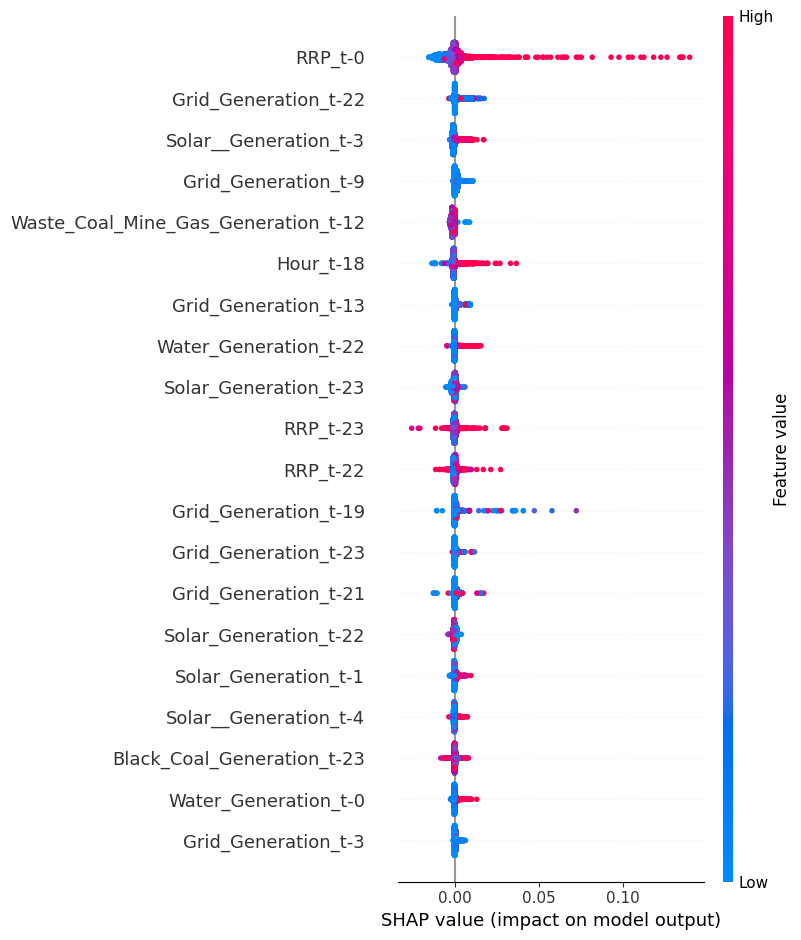

ValueError: visualize() can only display Explanation objects (or arrays of them)!

In [171]:
# Step 1: Prepare your data
X = df_scada_price_qld.drop(['RRP'], axis=1)
y = df_scada_price_qld[['RRP']]

train_cutoff = int(0.8 * X.shape[0])
val_cutoff = int(0.9 * X.shape[0])

# Normalize target
scaler_y = MinMaxScaler()
scaler_y.fit(y[:train_cutoff])
y_norm = scaler_y.transform(y)

# Concatenate X and y_norm
hist_size = 24
data_norm = np.concatenate((X, y_norm), axis=1)

# Step 2: Windowing
X_train, y_train = windowing(data_norm[:train_cutoff, :], data_norm[:train_cutoff, -1], hist_size)
X_val, y_val     = windowing(data_norm[train_cutoff:val_cutoff, :], data_norm[train_cutoff:val_cutoff, -1], hist_size)
X_test, y_test   = windowing(data_norm[val_cutoff:, :], data_norm[val_cutoff:, -1], hist_size)

# Step 3: Reshape and create feature names
def reshaping_with_names(X, feature_names):
    reshaped_x = X.reshape(X.shape[0], -1)
    col_names = [f"{name}_t-{hist_size - t - 1}" for t in range(hist_size) for name in feature_names]
    df_reshaped = pd.DataFrame(reshaped_x, columns=col_names)
    return df_reshaped

original_features = list(X.columns) + ['RRP']
X_train_xgb = reshaping_with_names(X_train, original_features)
X_val_xgb   = reshaping_with_names(X_val, original_features)
X_test_xgb  = reshaping_with_names(X_test, original_features)

# Step 4: Train XGBoost
model = xgb.XGBRegressor(objective="reg:squarederror", eval_metric="rmse")
model.fit(X_train_xgb, y_train)

# Step 5: SHAP
explainer = shap.Explainer(model, X_train_xgb)
shap_values = explainer(X_test_xgb)

# Step 6: SHAP Summary Plot with feature names
shap.summary_plot(shap_values, X_test_xgb)

# Step 7: SHAP Force Plot for single instance
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X_test_xgb.iloc[0])
